In [1]:
# imports

import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 38

torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
target = Path("data/metadata.csv")     # metadata file relative location

if not target.exists():    # if it doesn't exis, create it
    def create_metadata():
        # paths to all folders
        celeb_real = Path("raw_datasets/Celeb-real")
        celeb_fake = Path("raw_datasets/Celeb-synthesis")
        ff_real = Path("raw_datasets/FaceForensics++_C23/original")
        ff_fake = Path("raw_datasets/FaceForensics++_C23")
        ff_fake_dirs = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap", "NeuralTextures"]
    
        data = []

        # root folder to dataset
        base_dir = Path("data")

        # list celeb-df data
        for vid in celeb_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "label": 0
            })
    
        for vid in celeb_fake.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "Celeb-DF",
                "label": 1
            })

        # list FF++ data
        for vid in ff_real.glob("*.mp4"):
            data.append({
                "path": str(vid),
                "source": "FF++",
                "label": 0
            })
    
        for dirs in ff_fake_dirs:
            for vid in (ff_fake/dirs).glob("*.mp4"):
                data.append({
                "path": str(vid),
                "source": "FF++",
                "label": 1
            })

        # make a dataframe and store it as csv for future use
        df = pd.DataFrame(data);
        Path("data").mkdir(exist_ok=True)
        df.to_csv(target, index=False)


        #indicate completion
        print("**************************")
        print("Metadata Created Successfully")
        print("**************************")
    
    
    create_metadata()   # runs only when metadata.csv doesn't exist

In [3]:
df = pd.read_csv("data/metadata.csv")
df      #view the data frame

,path,source,label
0,raw_datasets\Celeb-real\id0_0000.mp4,Celeb-DF,0
1,raw_datasets\Celeb-real\id0_0001.mp4,Celeb-DF,0
2,raw_datasets\Celeb-real\id0_0002.mp4,Celeb-DF,0
3,raw_datasets\Celeb-real\id0_0003.mp4,Celeb-DF,0
4,raw_datasets\Celeb-real\id0_0004.mp4,Celeb-DF,0
...,...,...,...
12224,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12225,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12226,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1
12227,raw_datasets\FaceForensics++_C23\NeuralTexture...,FF++,1


In [4]:
# separate by source
celeb_df = df[df["source"]=="Celeb-DF"]
ff_df = df[df["source"]=="FF++"]

# shuffle it for better split
celeb_df = celeb_df.sample(frac=1, random_state=42)
ff_df = ff_df.sample(frac=1, random_state=42)

# determine train dataset split for both 
train_celeb_size = int(0.7 * len(celeb_df))
train_ff_size = int(0.7 * len(ff_df))

# concatenate train set from both sources evenly
train_df = pd.concat([celeb_df[:train_celeb_size], ff_df[:train_ff_size]]).reset_index(drop=True)

# repeat the same for val and test

val_test_celeb_size = int(0.15 * len(celeb_df))
val_test_ff_size = int(0.15 * len(ff_df))

val_df = pd.concat([celeb_df[train_celeb_size: train_celeb_size + val_test_celeb_size], ff_df[train_ff_size: train_ff_size + val_test_ff_size]]).reset_index(drop=True)
test_df = pd.concat([celeb_df[train_celeb_size + val_test_celeb_size:], ff_df[train_ff_size + val_test_ff_size:]]).reset_index(drop=True)


print("Train data:", len(train_df))
print("Val data:", len(val_df))
print("Test data:", len(test_df))

Train data: 8560
Val data: 1834
Test data: 1835


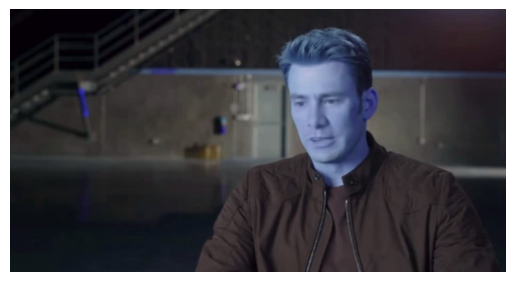

In [5]:
# frame extraction function to save frames in memory

def extract_frames(vid_path, num_frames = 30, resize=None):
    vid_path = Path(vid_path)

    cap = cv2.VideoCapture(str(vid_path))

    if not cap.isOpened():
        print(f"Error opening video: {vid_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        print(f"No frames found in: {vid_path}")
        return

    interval = max(total_frames // num_frames, 1)

    frames = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % interval == 0:

            if resize is not None:
                frame = cv2.resize(frame, resize)

            frames.append(frame)

            if len(frames) >=  num_frames:
                break

        frame_id += 1

    cap.release()
    return frames

# function demo
output = extract_frames(train_df["path"][0])
plt.imshow(output[29])
plt.axis('off')
plt.show()

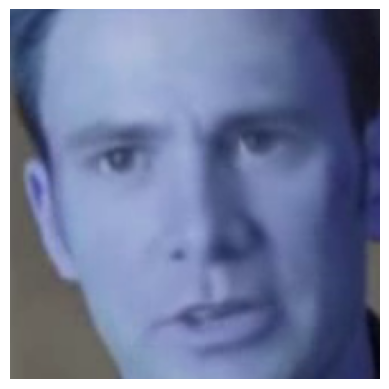

In [6]:
# face detection at frame 0 and face tracing on rest of frame for accurate crop

face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def face_detect_trace(vid_path):
    faces = []

    frames = extract_frames(vid_path)

    first = frames[0]
    gray = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)

    detected = face_detector.detectMultiScale(gray, 1.3, 5)

    if len(detected) == 0:
        frames = [cv2.resize(f, (224, 224)) for f in frames]
        return frames

    x,y,w,h = detected[0]

    tracker = cv2.legacy.TrackerCSRT_create()
    tracker.init(first, (x,y,w,h))

    for frame in frames:
        h_frame, w_frame = frame.shape[:2]
        success, box = tracker.update(frame)

        if success:
            x,y,w,h = [int(v) for v in box]
            x = max(0, x)
            y = max(0, y)
            w = max(1, min(w, w_frame - x))
            h = max(1, min(h, h_frame - y))
            
            face = frame[y: y + h, x: x + w]

            if face is None or face.size == 0:
                face = cv2.resize(frame, (224, 224))
            else:
                face = cv2.resize(face, (224, 224))
            faces.append(face)
        else:
            frame = cv2.resize(frame, (224, 224))
            faces.append(frame)

    return faces

# function demo
faces = face_detect_trace(train_df["path"][0])

plt.imshow(faces[10])
plt.axis("off")
plt.show()

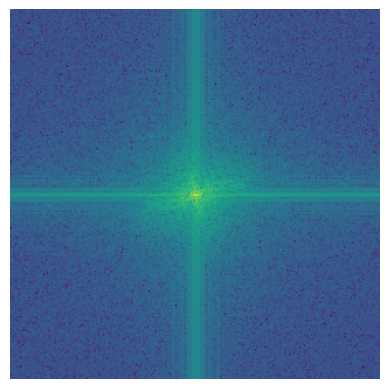

In [7]:
# applying frequency transform

def fft_transform(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return magnitude.astype(np.uint8)

# function demo
freq = fft_transform(faces[10])
plt.imshow(freq)
plt.axis("off")
plt.show()

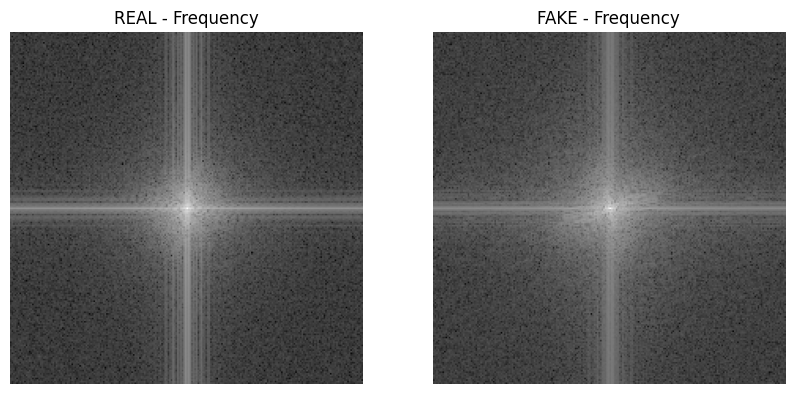

In [8]:
real_path = train_df[train_df["label"]==0].iloc[0]["path"]
real_faces = face_detect_trace(real_path)
real_freq = fft_transform(real_faces[10])

fake_path = train_df[train_df["label"]==1].iloc[0]["path"]
fake_faces = face_detect_trace(fake_path)
fake_freq = fft_transform(fake_faces[10])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_freq, cmap="gray")
plt.title("REAL - Frequency")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_freq, cmap="gray")
plt.title("FAKE - Frequency")
plt.axis("off")

plt.show()

Training Dataset
torch.Size([30, 3, 224, 224])
torch.Size([30, 1, 224, 224])
tensor(1.)


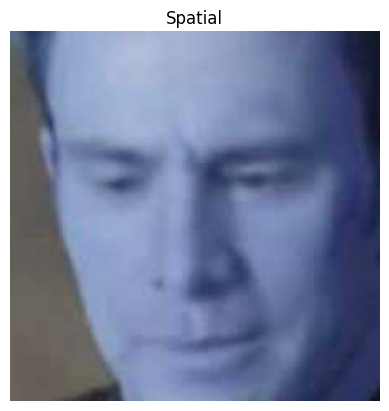

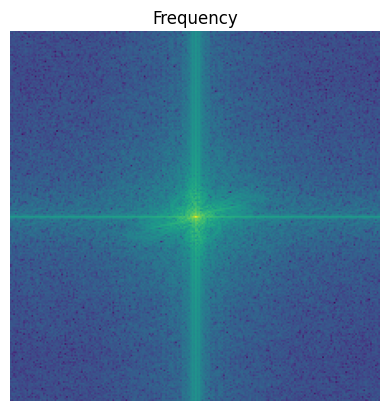

In [9]:
def compress_image(img, quality=50):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, enc = cv2.imencode('.jpg', img, encode_param)
    img = cv2.imdecode(enc, 1)
    return img

def augment_frame(img):
    if np.random.rand() < 0.5:
        img = compress_image(img, quality=np.random.randint(30, 70))

    if np.random.rand() < 0.3:
        img = cv2.GaussianBlur(img, (5,5), 0)

    if np.random.rand() < 0.3:
        noise = np.random.normal(0, 10, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

    if np.random.rand() < 0.3:
        alpha = np.random.uniform(0.8, 1.2)
        beta = np.random.uniform(-20, 20)
        img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

    if np.random.rand() < 0.3:
        img = cv2.flip(img, 1)

    return img

class DeepfakeDataset(Dataset):
    
    def __init__(self, df, num_frames = 30, mode = "train"):
        self.df = df
        self.num_frames = num_frames
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        video_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label"]

        faces = face_detect_trace(video_path)

        if self.mode == "train":
            faces = [augment_frame(face) for face in faces]

        if faces is None or len(faces) == 0:
            faces = [np.zeros((224, 224, 3), dtype=np.uint8) for _ in range(self.num_frames)]

        if len(faces) < self.num_frames:
            faces += [faces[-1]] * (self.num_frames - len(faces))

        freqs = [fft_transform(face) for face in faces]

        spatial = np.stack(faces)
        spatial = torch.tensor(spatial).permute(0, 3, 1, 2).float() / 255.0

        freqs = np.stack(freqs)
        freqs = torch.tensor(freqs).unsqueeze(1).float() / 255.0

        label = torch.tensor(label).float()

        return {
            "spatial": spatial,
            "frequency": freqs,
            "label": label
        }

train_dataset = DeepfakeDataset(train_df)

sample = train_dataset[0]

print("Training Dataset")
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

plt.imshow(sample["spatial"][0].permute(1, 2, 0))
plt.title("Spatial")
plt.axis("off")
plt.show()

plt.imshow(sample["frequency"][0][0])
plt.title("Frequency")
plt.axis("off")
plt.show()

In [10]:
print("Validation Dataset")
val_dataset = DeepfakeDataset(val_df,  mode="val")
sample = val_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])
print("\n\nTest Dataset")
test_dataset = DeepfakeDataset(test_df, mode="test")
sample = test_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Validation Dataset
torch.Size([30, 3, 224, 224])
torch.Size([30, 1, 224, 224])
tensor(1.)


Test Dataset
torch.Size([30, 3, 224, 224])
torch.Size([30, 1, 224, 224])
tensor(1.)


In [11]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [12]:
class Model0(nn.Module):
    def __init__(self):
        super().__init__()

        self.spatial_net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.freq_net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding = 1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(16 + 8, 1)

    def forward(self, spatial, frequency):
        B, T, C, H, W = spatial.shape

        spatial = spatial.view(B * T, C, H, W)
        frequency = frequency.view(B * T, 1, H, W)

        s_feat = self.spatial_net(spatial)
        f_feat = self.freq_net(frequency)

        s_feat = s_feat.view(B, T, -1)
        f_feat = f_feat.view(B, T, -1)

        s_feat = s_feat.mean(dim = 1)
        f_feat = f_feat.mean(dim = 1)

        combined = torch.cat([s_feat, f_feat], dim = 1)
        out = self.fc(combined)
        return out

model = Model0()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(3):
    print(f"---------EPOCH {epoch}----------")
    for batch in train_loader:
        spatial = batch["spatial"]
        frequency = batch["frequency"]
        labels = batch["label"].unsqueeze(1)

        outputs = model(spatial, frequency)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

---------EPOCH 0----------


KeyboardInterrupt: 